In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_data= ("../data/chest_xray/train")
test_data=("../data/chest_xray/test")
val_data=("../data/chest_xray/val")

In [29]:
train_datagen= ImageDataGenerator(
    rescale= 1./255, 
    rotation_range= 20, 
    zoom_range=0.2, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    horizontal_flip=True
    )

test_datagen= ImageDataGenerator(
    rescale= 1./255
)

In [30]:
train_image= train_datagen.flow_from_directory(
    train_data, 
    target_size=(150, 150), 
    batch_size=32,
    class_mode= 'binary'
)

test_image= test_datagen.flow_from_directory(
    test_data, 
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_image= test_datagen.flow_from_directory(
    val_data,
    target_size=(150, 150),
    batch_size=32, 
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [31]:
print(train_image.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


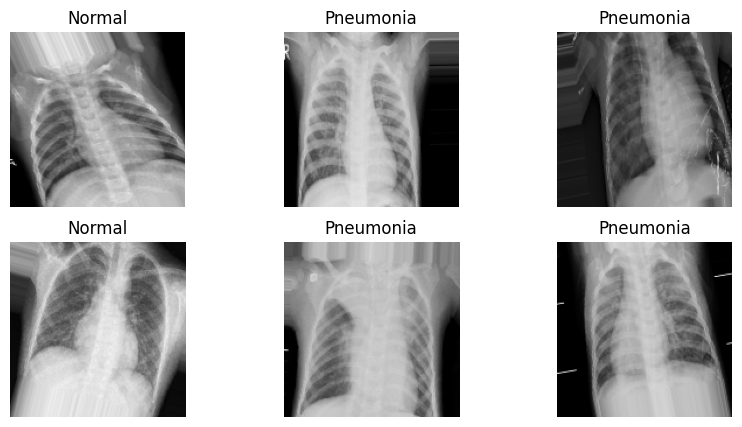

In [32]:
images, labels= next(train_image)

plt.figure(figsize=(10, 5))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] ==1 else "Normal")
    plt.axis("off")
    
plt.show()

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, Dense

In [34]:
model=Sequential()

In [35]:
model.add(
    Conv2D(
        32, 
        (3,3),
        activation= 'relu',
        input_shape= (150,150,3)
    )
)

/opt/anaconda3/envs/pneumonia/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.add(MaxPooling2D(2,2))

In [37]:
model.add(Conv2D (64, (3,3), activation='relu'))
model.add(MaxPooling2D (2,2))

In [38]:
model.add(Conv2D (128, (3,3), activation='relu'))
model.add(MaxPooling2D (2,2))

In [39]:
model.add(Flatten())

In [40]:
model.add(Dense(128, activation= 'relu'))
model.add(Dropout(0.5))
model.add(Dense (1, activation = 'sigmoid'))

In [41]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics= ['accuracy']
)

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
early_stop=EarlyStopping(
    monitor= 'val_loss',
    patience=3,
    restore_best_weights=True
)

In [48]:
history= model.fit(
    train_image, 
    validation_data= val_image,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.7855 - loss: 0.4763 - val_accuracy: 0.8125 - val_loss: 0.4845
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 28s 172ms/step - accuracy: 0.8553 - loss: 0.3263 - val_accuracy: 0.8125 - val_loss: 0.5495
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.8790 - loss: 0.2780 - val_accuracy: 0.7500 - val_loss: 0.4873
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 183ms/step - accuracy: 0.8913 - loss: 0.2606 - val_accuracy: 0.8750 - val_loss: 0.5986


In [49]:
test_loss, test_accuracy= model.evaluate(test_image)

print("Test Loss: ", test_loss)
print("Test Accuracy", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.8013 - loss: 0.4613
Test Loss:  0.4612590968608856
Test Accuracy 0.8012820482254028


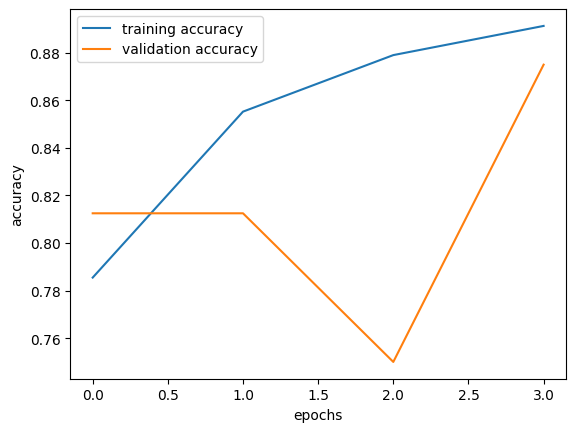

In [50]:
plt.plot(history.history['accuracy'], label= 'training accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()

plt.show()

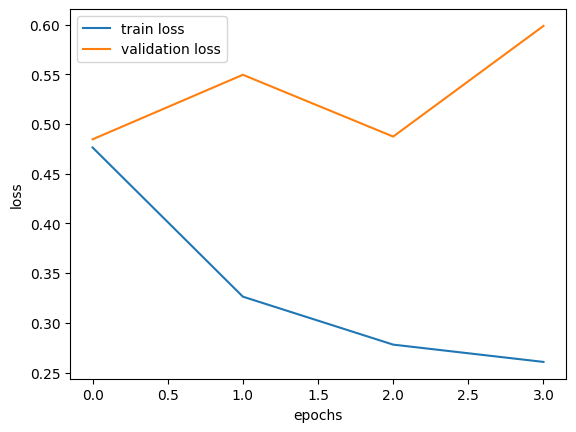

In [51]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()

plt.show()